# 01. EDA — 지정 배터리 데이터의 특성
울산캠퍼스 1반 김진형 · 회귀 과제

Batch 1: 2017-05-12 / 필수 Batch 2: 2018-02-20 / 추가 Batch 3: 2018-04-12.
전체 열화와 knee는 사후 설명이며 초기 예측 입력에서 제외한다.

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
from IPython.display import display, Image, Markdown
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 4)
def show_plot(name):
    display(Image(filename=str(ROOT / f'results/figures/{name}.png')))


## 데이터 품질과 제외 기준

In [2]:
audit = json.loads((ROOT/'results/quality_audit.json').read_text())
print(audit['raw_counts'], '→', audit['analysis_counts'])
display(pd.read_csv(ROOT/'results/cell_exclusions.csv')[['cell_id','batch','reasons']])

{'1': 46, '2': 47, '3': 46} → {'1': 36, '2': 39, '3': 40}


,cell_id,batch,reasons
0,b1c0,1,EOL_not_observed_or_incomplete_record
1,b1c1,1,EOL_not_observed_or_incomplete_record
2,b1c2,1,EOL_not_observed_or_incomplete_record
3,b1c3,1,EOL_not_observed_or_incomplete_record
4,b1c4,1,EOL_not_observed_or_incomplete_record
5,b1c8,1,EOL_not_observed_or_incomplete_record
6,b1c10,1,EOL_not_observed_or_incomplete_record
7,b1c12,1,EOL_not_observed_or_incomplete_record
8,b1c13,1,EOL_not_observed_or_incomplete_record
9,b1c22,1,EOL_not_observed_or_incomplete_record


## Q1. 수명 분포와 배치 차이
Batch 2에는 학습 분포보다 짧은 수명의 셀이 많다. 불완료 기록 제외에 따른 장수명 선택 편향도 고려한다.

,batch,n,mean,median,std,min,q25,q75,max,short_n,short_pct,long_n,long_pct,capacity_increase_pct,median_capacity_change_pct,n_policy
0,1,36,788.4167,772.5,148.6957,534.0,681.00,871.50,1074.0,0,0.0000,5,13.8889,88.8889,0.2202,20
1,2,39,565.7436,472.0,222.2016,392.0,439.50,508.50,1186.0,28,71.7949,3,7.6923,64.1026,0.1977,12
2,3,40,1032.0000,964.5,308.5984,541.0,827.25,1122.75,1935.0,0,0.0000,19,47.5000,85.0000,0.1297,8


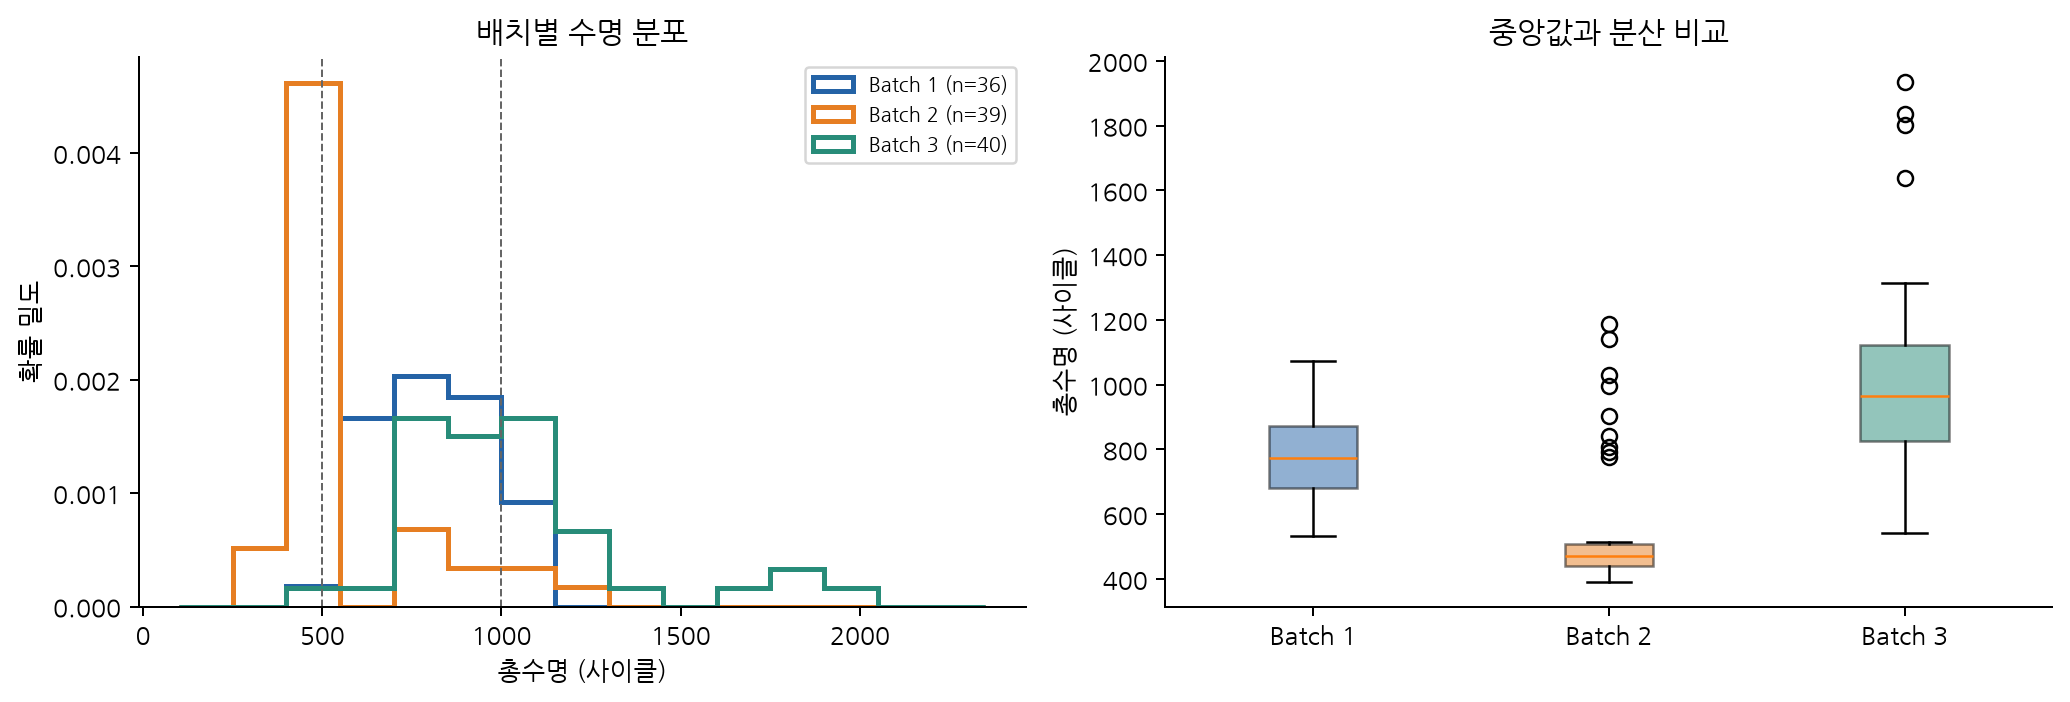

In [3]:
display(pd.read_csv(ROOT/'results/batch_statistics.csv'))
show_plot('01_cycle_life')

## Q2. 전체·초기 열화와 탐색적 knee
초기 용량의 증가와 말기 가속 열화를 구분한다. 미래 knee는 입력이 아니다.

,knee,knee_fraction
batch,,
1,579.0257,0.7483
2,340.6324,0.7489
3,796.6405,0.7955


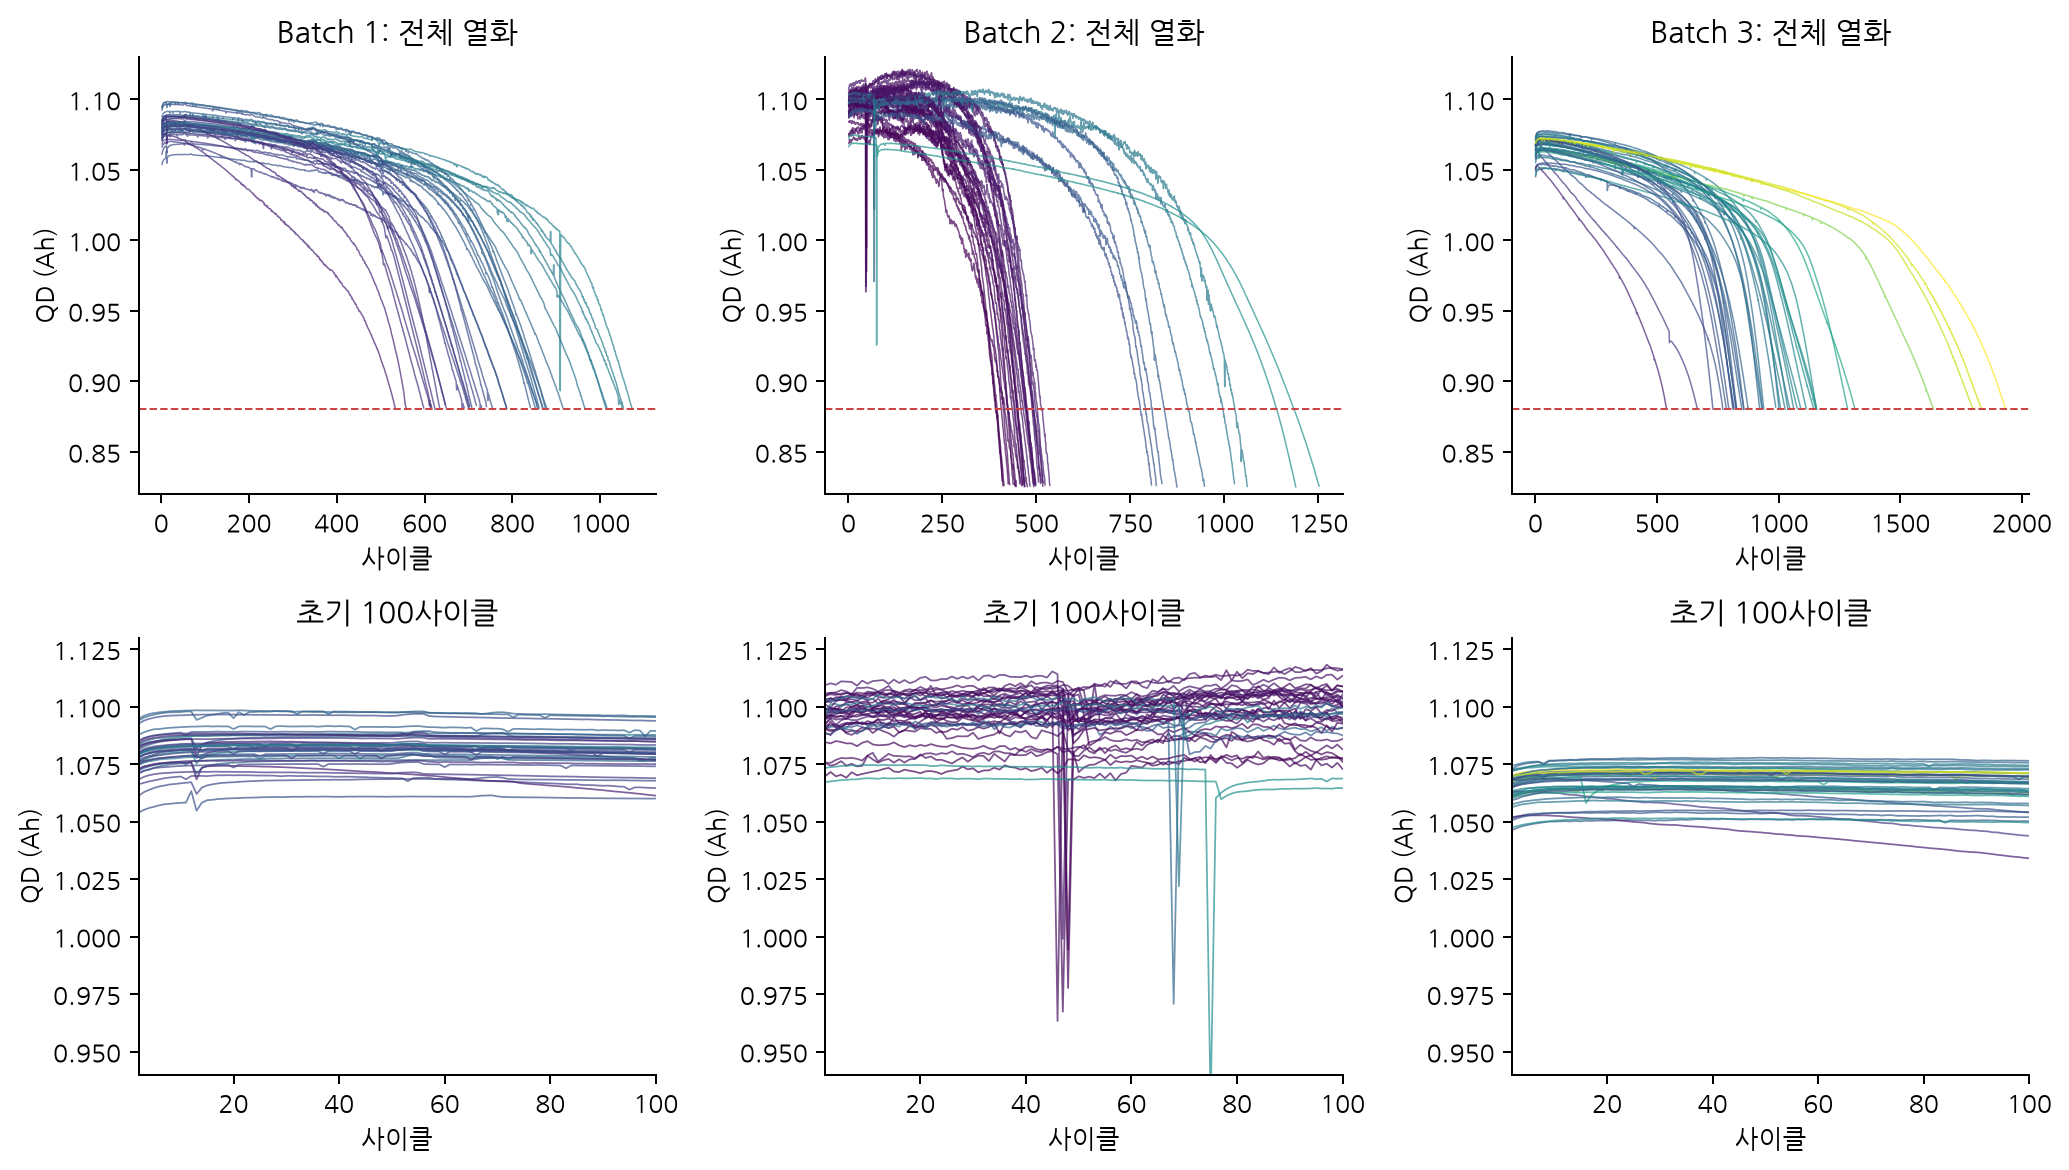

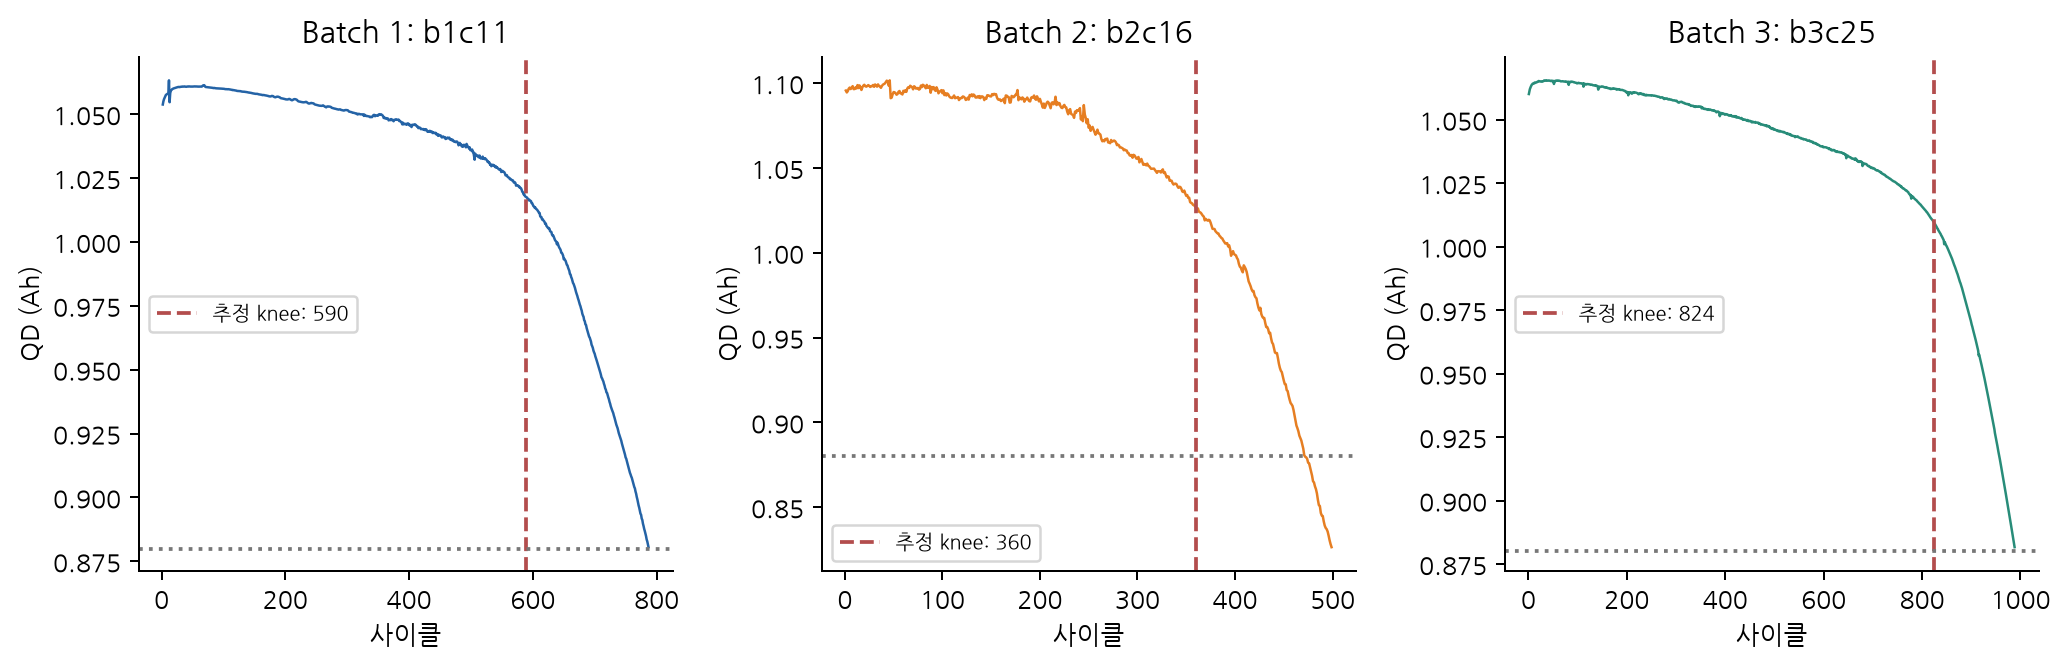

In [4]:
display(pd.read_csv(ROOT/'results/knee_estimates.csv').groupby('batch')[['knee','knee_fraction']].median())
show_plot('02_degradation')
show_plot('03_knee')

## Q3. ΔQ100−10(V)
제공 전압 격자와 실제 사이클 번호를 사용한다. 상관은 예측 성능 지표와 다르다.

Batch 1: r=-0.8435
Batch 2: r=-0.9184
Batch 3: r=-0.8046


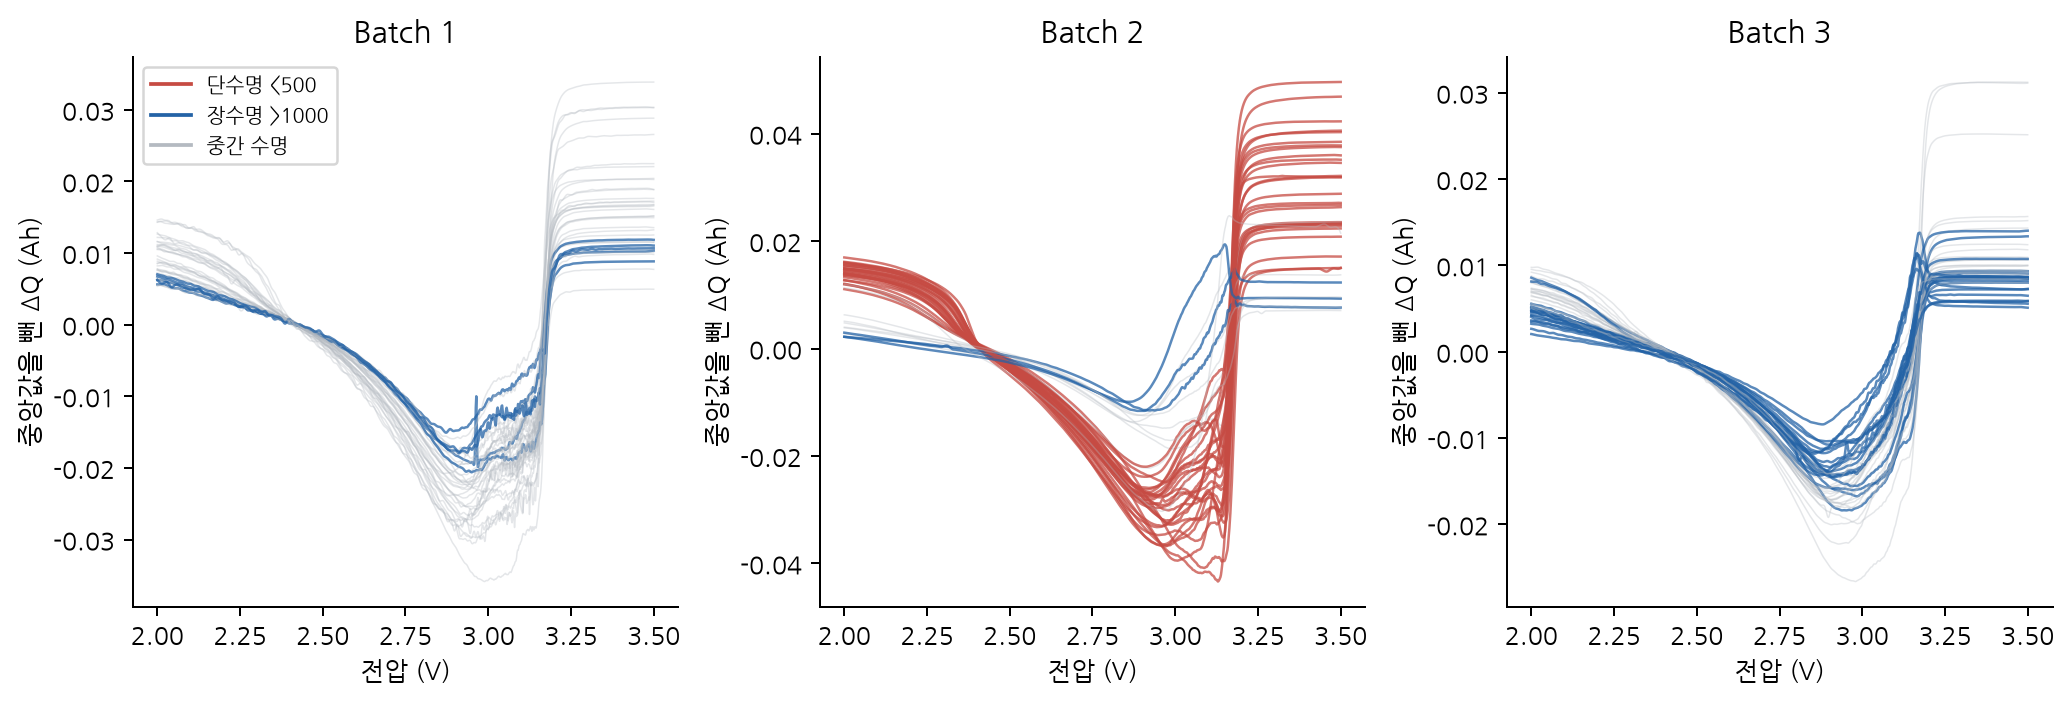

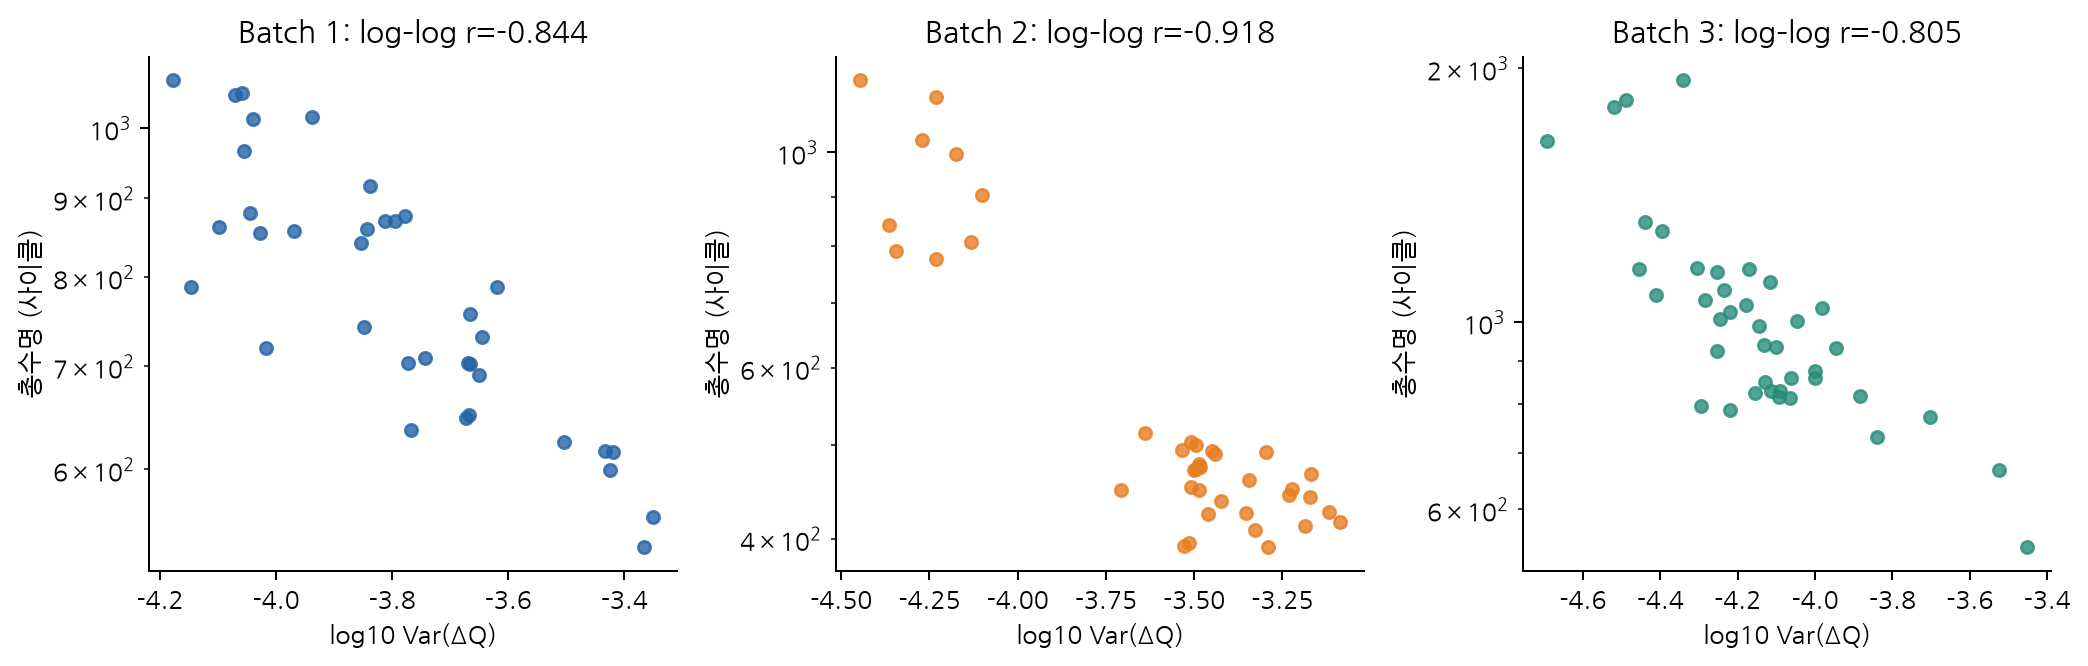

In [5]:
f = pd.read_csv(ROOT/'results/features.csv')
for batch, part in f.groupby('batch'):
    print(f'Batch {batch}: r={part.delta_q_logvar.corr(np.log10(part.cycle_life)):.4f}')
show_plot('04_delta_q')
show_plot('05_delta_q_life')

## Q4. 정책과 실측 충전 전류
같은 최대 전류라도 유지 SOC 구간과 실측 패턴이 다르다. 정책별 n이 작아 인과 효과를 단정하지 않는다.

,batch,charging_policy,mean,std,count
0,1,4.4C(80%)-4.4C,1074.0000,NaN,1
1,1,4.8C(80%)-4.8C,753.0000,165.4630,2
2,1,5.4C(40%)-3.6C,1054.0000,NaN,1
3,1,5.4C(50%)-3C,788.0000,NaN,1
4,1,5.4C(60%)-3.6C,859.5000,3.5355,2
5,1,5.4C(60%)-3C,799.5000,113.8442,2
6,1,5.4C(70%)-3C,739.5000,68.5894,2
7,1,5.4C(80%)-5.4C,546.5000,17.6777,2
8,1,6C(30%)-3.6C,1014.0000,NaN,1
9,1,6C(40%)-3.6C,856.0000,19.7990,2


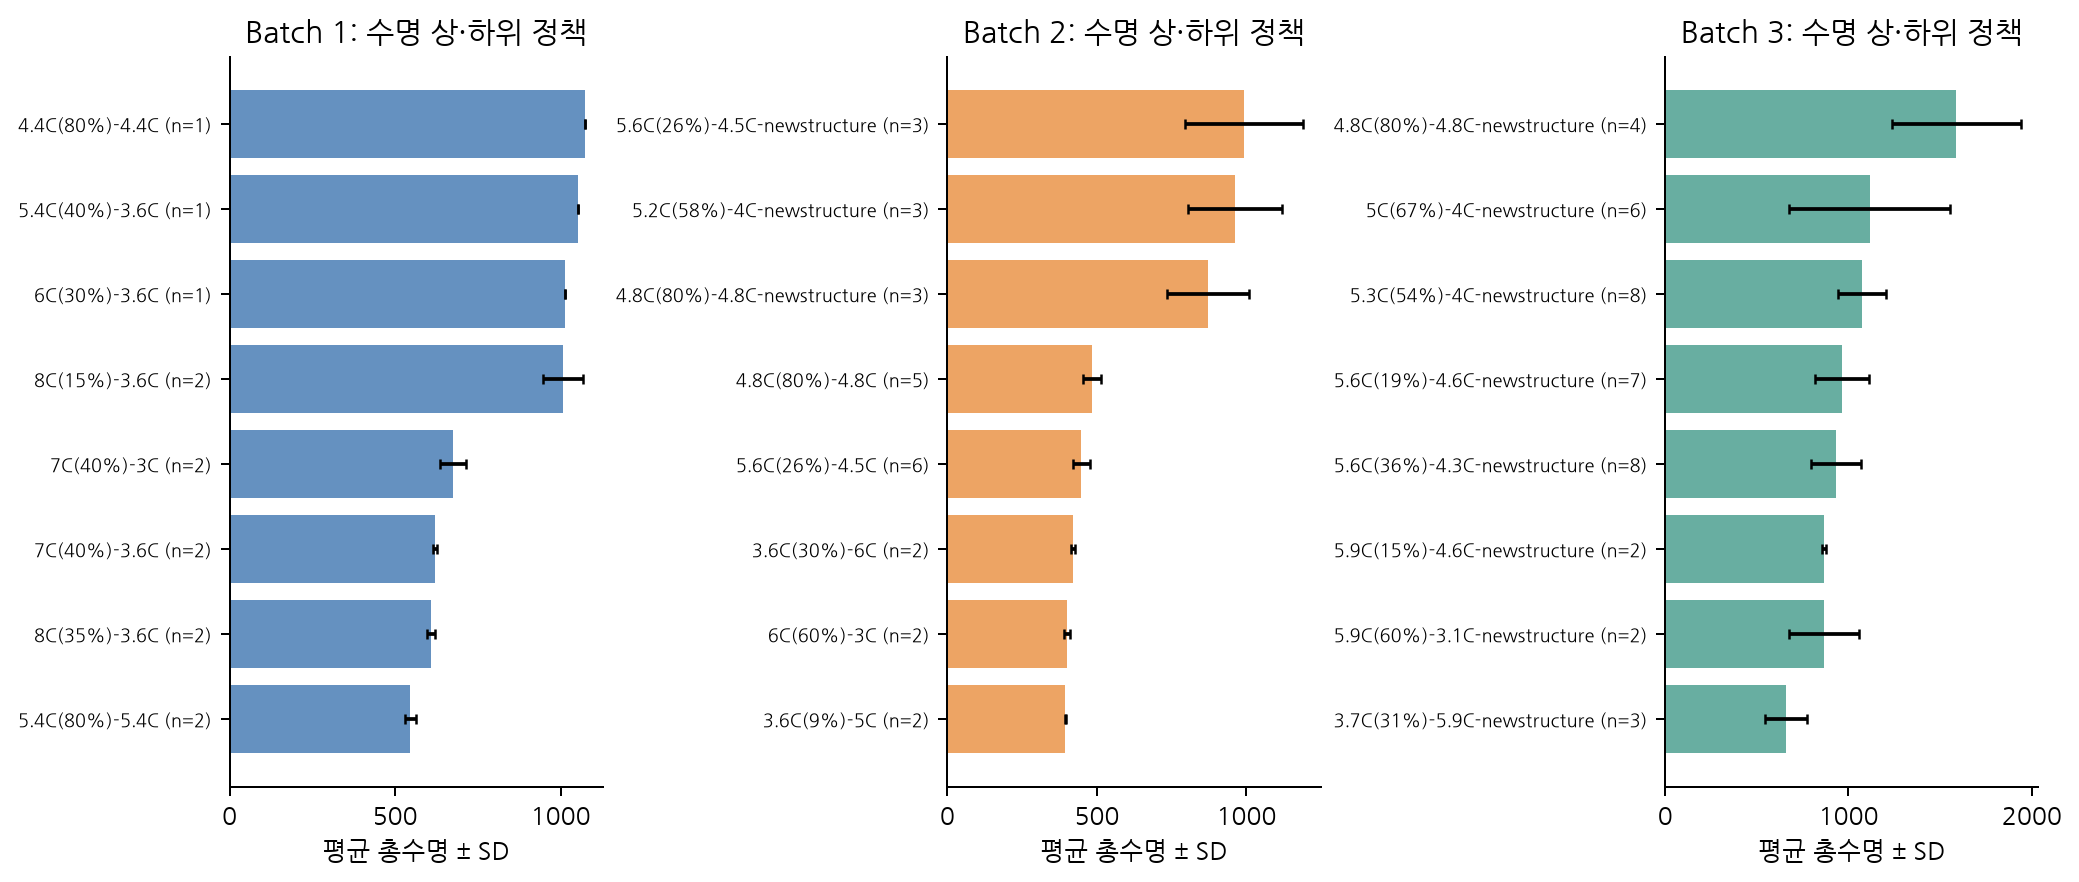

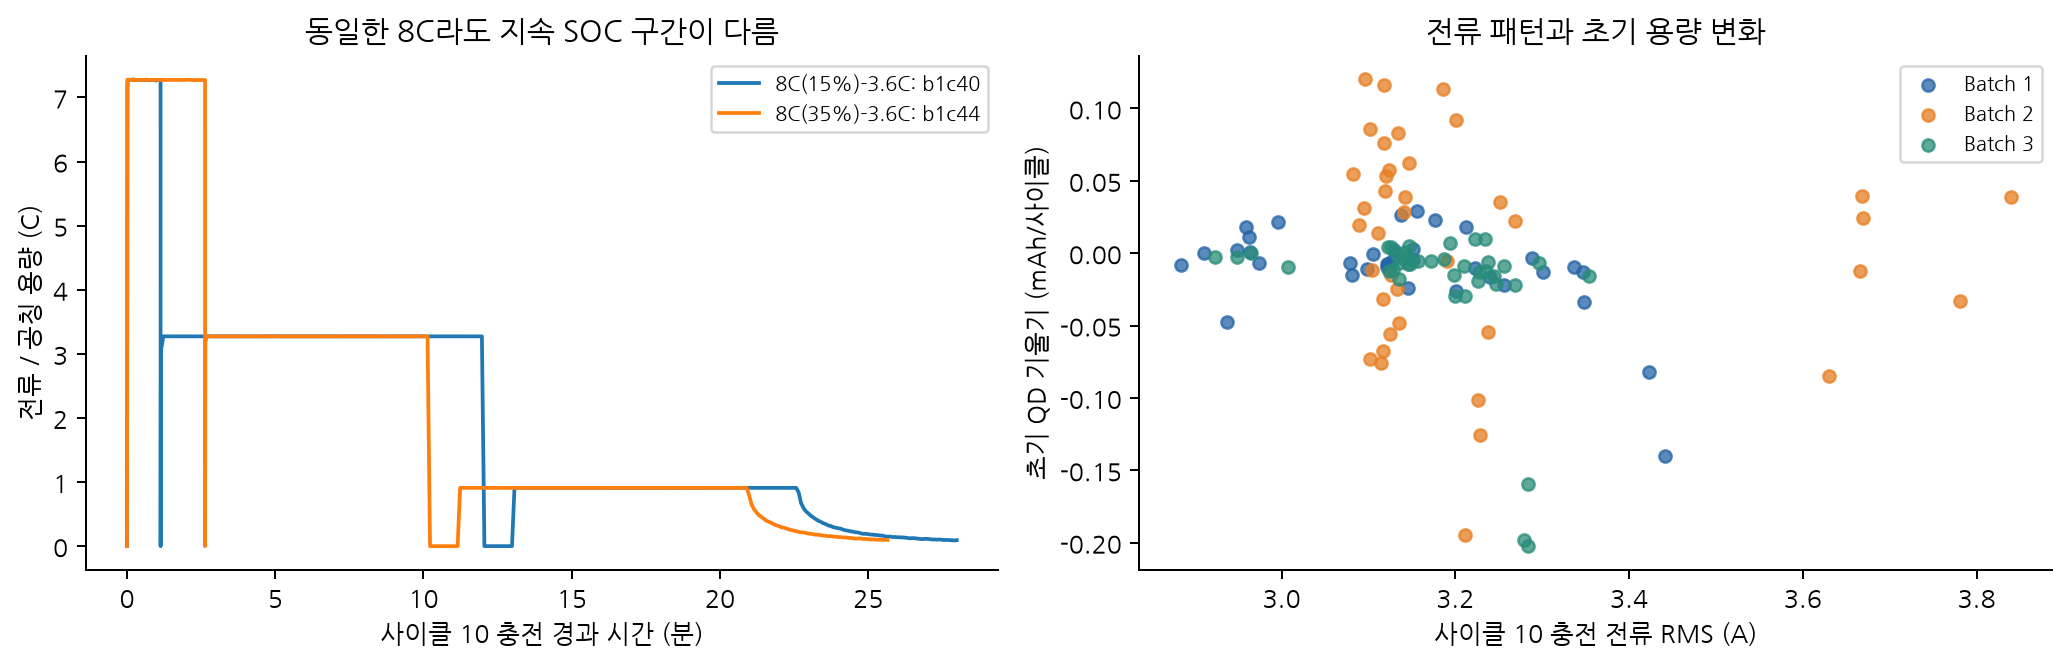

In [6]:
display(pd.read_csv(ROOT/'results/policy_statistics.csv'))
show_plot('06_policy')
show_plot('09_current_patterns')

## Q5. 강한 신호와 다중공선성
중복 신호에는 대표 변수와 규제를 사용하고 모델 비교로 추가 가치를 확인한다.

,batch,feature,n,pearson_life,pearson_loglife,spearman_life
0,1,delta_q_logvar,36,-0.8266,-0.8435,-0.8262
1,1,delta_q_min,36,0.8182,0.8365,0.8280
2,1,QD_2,36,0.1605,0.1566,0.1610
3,1,QD_slope,36,0.5078,0.5524,0.4725
4,1,IR_mean,36,0.2240,0.2541,0.1955
5,1,IR_change_100_2,36,0.1370,0.1356,-0.2251
6,1,Tavg_mean,36,-0.1727,-0.1561,-0.1164
7,1,Tmax_mean,36,-0.1633,-0.1506,-0.1025
8,1,chargetime_mean,36,0.4897,0.4898,0.4774
9,1,effective_c_rate,36,-0.5798,-0.5939,-0.4349


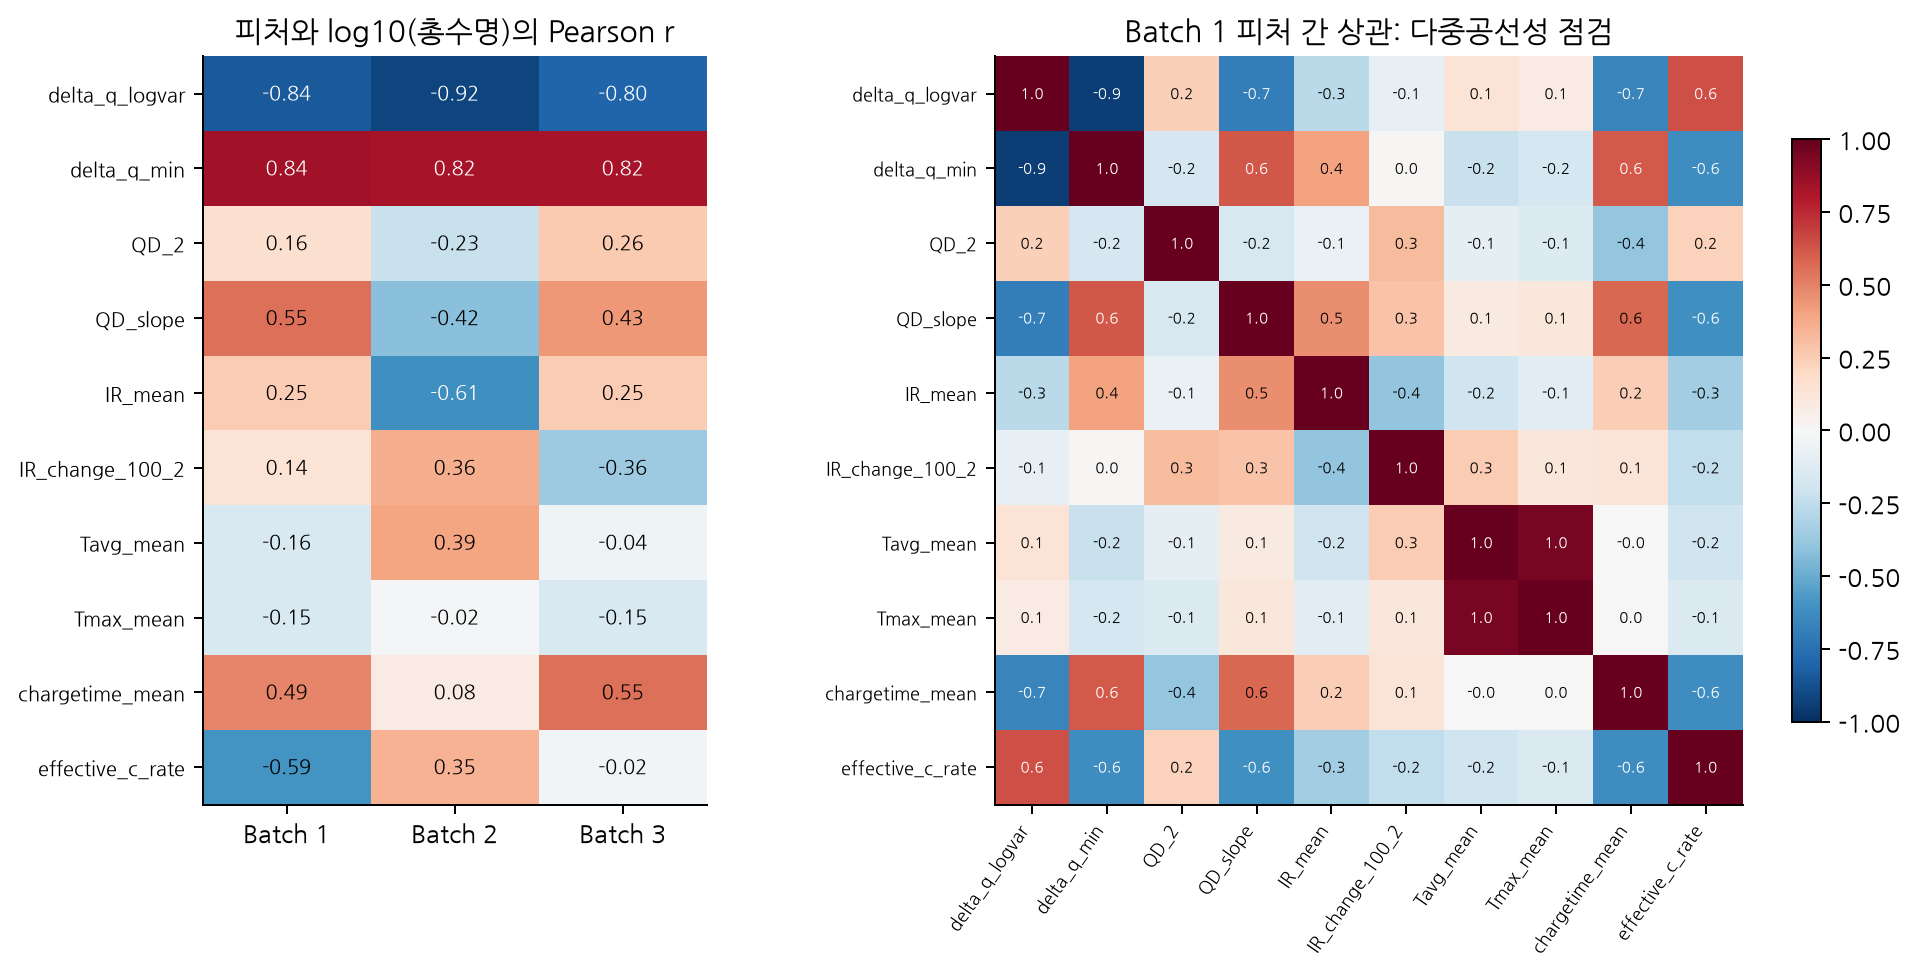

In [7]:
display(pd.read_csv(ROOT/'results/feature_correlations.csv'))
show_plot('08_correlations')